In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/gps_collected.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (24876978, 8)


In [3]:
df.head()

,user_id,latitude,longitude,altitude,date_days,date,time,timestamp
0,135,39.974294,116.399741,492.0,39816.056644,2009-01-03,01:21:34,2009-01-03 01:21:34
1,135,39.974292,116.399592,492.0,39816.056655,2009-01-03,01:21:35,2009-01-03 01:21:35
2,135,39.974309,116.399523,492.0,39816.056667,2009-01-03,01:21:36,2009-01-03 01:21:36
3,135,39.974320,116.399588,492.0,39816.056690,2009-01-03,01:21:38,2009-01-03 01:21:38
4,135,39.974365,116.399730,491.0,39816.056701,2009-01-03,01:21:39,2009-01-03 01:21:39


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24876978 entries, 0 to 24876977
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   user_id    int64  
 1   latitude   float64
 2   longitude  float64
 3   altitude   float64
 4   date_days  float64
 5   date       str    
 6   time       str    
 7   timestamp  str    
dtypes: float64(4), int64(1), str(3)
memory usage: 1.5 GB


In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
user_id      0
latitude     0
longitude    0
altitude     0
date_days    0
date         0
time         0
timestamp    0
dtype: int64


In [6]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

print(missing_percentage)

user_id      0.0
latitude     0.0
longitude    0.0
altitude     0.0
date_days    0.0
date         0.0
time         0.0
timestamp    0.0
dtype: float64


In [7]:
df = df.dropna(
    subset=["latitude", "longitude"]
)

print("Shape after removing missing coordinates:")
print(df.shape)

Shape after removing missing coordinates:
(24876978, 8)


In [8]:
df = df[
    (df["latitude"] >= -90) &
    (df["latitude"] <= 90)
]

print("Shape after latitude validation:", df.shape)

Shape after latitude validation: (24876977, 8)


In [9]:
df = df[
    (df["longitude"] >= -180) &
    (df["longitude"] <= 180)
]

print("Shape after longitude validation:", df.shape)

Shape after longitude validation: (24876977, 8)


In [10]:
duplicates = df.duplicated().sum()

print("Duplicate records:", duplicates)

Duplicate records: 146900


In [11]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (24730077, 8)


In [12]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

print(df["timestamp"].dtype)

datetime64[us]


In [13]:
df = df.dropna(
    subset=["timestamp"]
)

print("Shape after timestamp cleaning:", df.shape)

Shape after timestamp cleaning: (24730077, 8)


In [14]:
df["hour"] = df["timestamp"].dt.hour

df[["timestamp", "hour"]].head()

,timestamp,hour
0,2009-01-03 01:21:34,1
1,2009-01-03 01:21:35,1
2,2009-01-03 01:21:36,1
3,2009-01-03 01:21:38,1
4,2009-01-03 01:21:39,1


In [15]:
df["day"] = df["timestamp"].dt.day

df[["timestamp", "day"]].head()

,timestamp,day
0,2009-01-03 01:21:34,3
1,2009-01-03 01:21:35,3
2,2009-01-03 01:21:36,3
3,2009-01-03 01:21:38,3
4,2009-01-03 01:21:39,3


In [16]:
df["weekday"] = df["timestamp"].dt.day_name()

df[["timestamp", "weekday"]].head()

,timestamp,weekday
0,2009-01-03 01:21:34,Saturday
1,2009-01-03 01:21:35,Saturday
2,2009-01-03 01:21:36,Saturday
3,2009-01-03 01:21:38,Saturday
4,2009-01-03 01:21:39,Saturday


In [17]:
df["month"] = df["timestamp"].dt.month

df[["timestamp", "month"]].head()

,timestamp,month
0,2009-01-03 01:21:34,1
1,2009-01-03 01:21:35,1
2,2009-01-03 01:21:36,1
3,2009-01-03 01:21:38,1
4,2009-01-03 01:21:39,1


In [18]:
df["is_weekend"] = df["timestamp"].dt.dayofweek >= 5

df[
    ["timestamp", "weekday", "is_weekend"]
].head(10)

,timestamp,weekday,is_weekend
0,2009-01-03 01:21:34,Saturday,True
1,2009-01-03 01:21:35,Saturday,True
2,2009-01-03 01:21:36,Saturday,True
3,2009-01-03 01:21:38,Saturday,True
4,2009-01-03 01:21:39,Saturday,True
5,2009-01-03 01:21:42,Saturday,True
6,2009-01-03 01:21:46,Saturday,True
7,2009-01-03 01:21:51,Saturday,True
8,2009-01-03 01:21:56,Saturday,True
9,2009-01-03 01:22:01,Saturday,True


In [19]:
df = df.sort_values(
    by=["user_id", "timestamp"]
).reset_index(drop=True)

df.head()

,user_id,latitude,longitude,altitude,date_days,date,time,timestamp,hour,day,weekday,month,is_weekend
0,0,39.984702,116.318417,492.0,39744.120185,2008-10-23,02:53:04,2008-10-23 02:53:04,2,23,Thursday,10,False
1,0,39.984683,116.318450,492.0,39744.120255,2008-10-23,02:53:10,2008-10-23 02:53:10,2,23,Thursday,10,False
2,0,39.984686,116.318417,492.0,39744.120313,2008-10-23,02:53:15,2008-10-23 02:53:15,2,23,Thursday,10,False
3,0,39.984688,116.318385,492.0,39744.120370,2008-10-23,02:53:20,2008-10-23 02:53:20,2,23,Thursday,10,False
4,0,39.984655,116.318263,492.0,39744.120428,2008-10-23,02:53:25,2008-10-23 02:53:25,2,23,Thursday,10,False


In [20]:
print("Final shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Final shape: (24730077, 13)

Columns:
['user_id', 'latitude', 'longitude', 'altitude', 'date_days', 'date', 'time', 'timestamp', 'hour', 'day', 'weekday', 'month', 'is_weekend']

Missing values:
user_id       0
latitude      0
longitude     0
altitude      0
date_days     0
date          0
time          0
timestamp     0
hour          0
day           0
weekday       0
month         0
is_weekend    0
dtype: int64


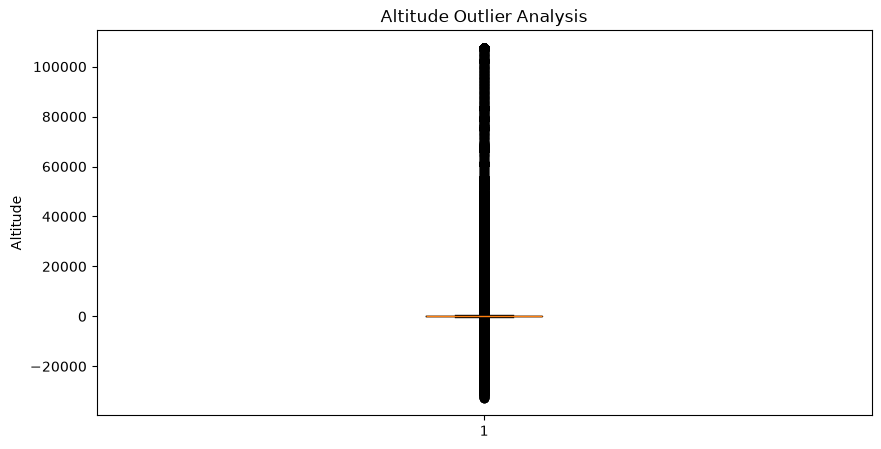

In [21]:
plt.figure(figsize=(10, 5))

plt.boxplot(df["altitude"].dropna())

plt.title("Altitude Outlier Analysis")
plt.ylabel("Altitude")

plt.show()

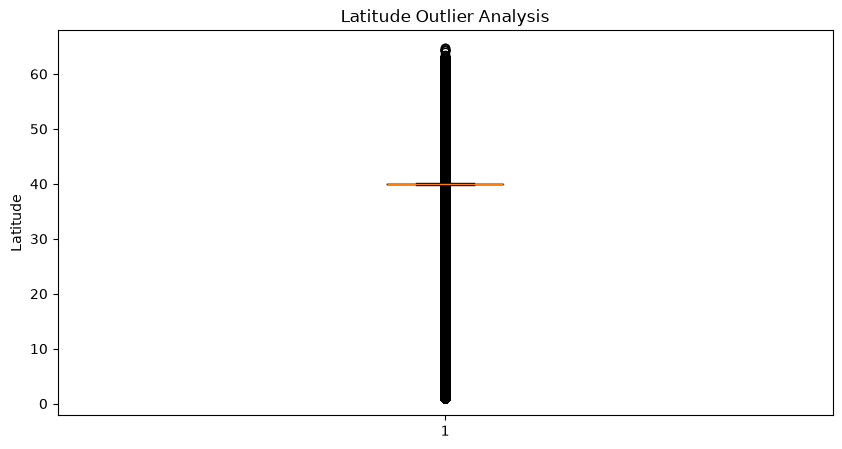

In [22]:
plt.figure(figsize=(10, 5))

plt.boxplot(df["latitude"].dropna())

plt.title("Latitude Outlier Analysis")
plt.ylabel("Latitude")

plt.show()

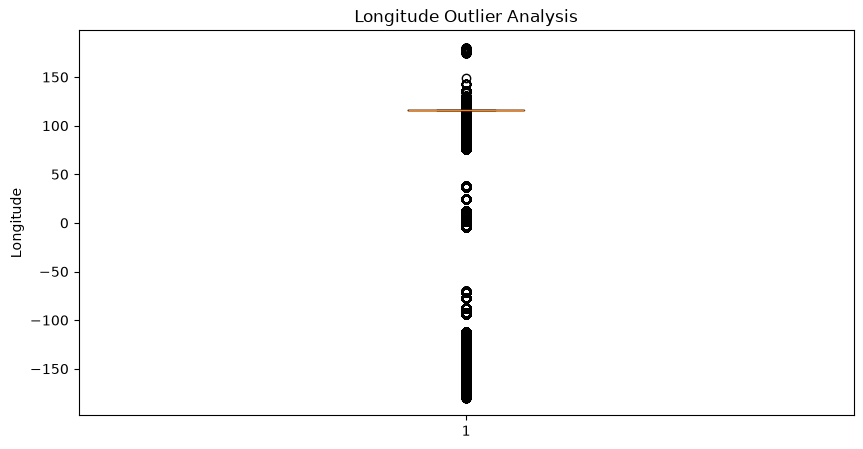

In [23]:
plt.figure(figsize=(10, 5))

plt.boxplot(df["longitude"].dropna())

plt.title("Longitude Outlier Analysis")
plt.ylabel("Longitude")

plt.show()

In [24]:
df_clean = df[
    [
        "user_id",
        "latitude",
        "longitude",
        "altitude",
        "date",
        "time",
        "timestamp",
        "hour",
        "day",
        "weekday",
        "month",
        "is_weekend"
    ]
].copy()

df_clean.head()

,user_id,latitude,longitude,altitude,date,time,timestamp,hour,day,weekday,month,is_weekend
0,0,39.984702,116.318417,492.0,2008-10-23,02:53:04,2008-10-23 02:53:04,2,23,Thursday,10,False
1,0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2008-10-23 02:53:10,2,23,Thursday,10,False
2,0,39.984686,116.318417,492.0,2008-10-23,02:53:15,2008-10-23 02:53:15,2,23,Thursday,10,False
3,0,39.984688,116.318385,492.0,2008-10-23,02:53:20,2008-10-23 02:53:20,2,23,Thursday,10,False
4,0,39.984655,116.318263,492.0,2008-10-23,02:53:25,2008-10-23 02:53:25,2,23,Thursday,10,False


In [25]:
output_path = "../data/processed/gps_cleaned.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print(output_path)

Cleaned dataset saved successfully!
../data/processed/gps_cleaned.csv


In [26]:
final_df = pd.read_csv(
    "../data/processed/gps_cleaned.csv"
)

print("Final dataset shape:", final_df.shape)

print("\nFirst 5 records:")
display(final_df.head())

print("\nMissing values:")
print(final_df.isnull().sum())

Final dataset shape: (24730077, 12)

First 5 records:


,user_id,latitude,longitude,altitude,date,time,timestamp,hour,day,weekday,month,is_weekend
0,0,39.984702,116.318417,492.0,2008-10-23,02:53:04,2008-10-23 02:53:04,2,23,Thursday,10,False
1,0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2008-10-23 02:53:10,2,23,Thursday,10,False
2,0,39.984686,116.318417,492.0,2008-10-23,02:53:15,2008-10-23 02:53:15,2,23,Thursday,10,False
3,0,39.984688,116.318385,492.0,2008-10-23,02:53:20,2008-10-23 02:53:20,2,23,Thursday,10,False
4,0,39.984655,116.318263,492.0,2008-10-23,02:53:25,2008-10-23 02:53:25,2,23,Thursday,10,False



Missing values:
user_id       0
latitude      0
longitude     0
altitude      0
date          0
time          0
timestamp     0
hour          0
day           0
weekday       0
month         0
is_weekend    0
dtype: int64
